# 03: EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white", palette="muted")
plt.rcParams['figure.autolayout'] = True

listings = pd.read_pickle('../listings_cleaned.pkl')
past_rates = pd.read_pickle('../past_rates_cleaned.pkl')

for col in ['ttm_revenue', 'ttm_occupancy', 'guests', 'bedrooms', 'amenity_count']:
    listings[col] = pd.to_numeric(listings[col], errors='coerce')

print("Clean Data Loaded")

Clean Data Loaded


## 0. Basic Data Exploration

In [2]:
listings.head()

,listing_id,listing_type,room_type,cover_photo_url,photos_count,host_id,superhost,latitude,longitude,guests,...,l90d_adjusted_revpar_native,l90d_reserved_days,l90d_blocked_days,l90d_available_days,l90d_total_days,country,state,city,amenity_list,amenity_count
0,121902,Entire home,entire_home,https://a0.muscache.com/im/pictures/77c0e3a9-0...,77,fe453949b595,false,37.0758,27.2426,6.0,...,0.0,0,90,90,90,Turkey,Muğla,Bodrum,"[tv, cable tv, wifi, air conditioning, pool, k...",75
1,805342,Entire condo,entire_home,https://a0.muscache.com/im/pictures/11494599/4...,16,59711ec4c245,false,37.0092,27.2563,3.0,...,0.0,0,0,90,90,Turkey,Muğla,Bodrum,"[high chair, tv, cable tv, wifi, waterfront, a...",33
2,805361,Entire home,entire_home,https://a0.muscache.com/im/pictures/bda48dbc-d...,34,d217bf6e3427,false,37.0292,27.4410,5.0,...,0.0,0,0,90,90,Turkey,Muğla,Bodrum,"[smoking allowed, gym, hair dryer, cleaning pr...",44
3,853827,Entire villa,entire_home,https://a0.muscache.com/im/pictures/26626113/a...,70,605fc7d80e02,false,37.0434,27.2517,16.0,...,0.0,2,0,88,90,Turkey,Muğla,Bodrum,"[hair dryer, hot water, washer, dryer, essenti...",18
4,967193,Entire villa,entire_home,https://a0.muscache.com/im/pictures/68107669/2...,37,3b963e8cd040,false,37.0429,27.3898,4.0,...,0.0,0,0,90,90,Turkey,Muğla,Bodrum,"[high chair, tv, washer, bbq grill, air condit...",12


In [3]:
listings.info()

<class 'pandas.DataFrame'>
Index: 94868 entries, 0 to 95437
Data columns (total 63 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   listing_id                   94868 non-null  object 
 1   listing_type                 94868 non-null  object 
 2   room_type                    94868 non-null  object 
 3   cover_photo_url              94641 non-null  object 
 4   photos_count                 94641 non-null  object 
 5   host_id                      94868 non-null  object 
 6   superhost                    94868 non-null  object 
 7   latitude                     94868 non-null  object 
 8   longitude                    94867 non-null  object 
 9   guests                       84463 non-null  float64
 10  bedrooms                     78103 non-null  float64
 11  beds                         93878 non-null  object 
 12  baths                        94529 non-null  object 
 13  registration                 945

In [4]:
listings.describe()

,guests,bedrooms,cleaning_fee,extra_guest_fee,num_reviews,rating_overall,rating_accuracy,rating_checkin,rating_cleanliness,rating_communication,...,ttm_available_days,ttm_total_days,l90d_revenue,l90d_revenue_native,l90d_avg_rate,l90d_avg_rate_native,l90d_occupancy,l90d_adjusted_occupancy,l90d_revpar,amenity_count
count,84463.000000,78103.000000,92882.000000,91592.000000,94782.000000,92263.000000,92263.000000,92263.000000,92264.000000,92265.000000,...,94868.000000,94868.000000,94868.000000,9.486800e+04,94868.000000,94868.000000,94868.000000,94868.000000,94867.000000,94868.000000
mean,4.406379,1.923486,47.255374,1.955266,115.865078,4.821647,5.319589,5.393128,4.905853,5.743791,...,250.878512,365.137948,2421.429378,1.314313e+04,151.492089,773.016587,0.174482,0.103823,25.519671,34.584939
std,2.375725,1.185518,108.383795,8.743133,148.372819,16.611207,91.614619,84.224033,28.181201,153.828693,...,82.915004,32.591952,4729.642043,1.551021e+05,172.019359,4226.828990,0.437577,0.630403,50.084351,13.789559
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.600000,1.700000,2.000000,0.266000,0.359000,...,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,1.000000,0.000000,0.000000,24.000000,4.680000,4.800000,4.800000,4.700000,4.800000,...,195.000000,365.000000,0.000000,0.000000e+00,70.400000,71.700000,0.000000,0.000000,0.000000,24.000000
50%,4.000000,2.000000,23.000000,0.000000,63.000000,4.820000,4.900000,4.900000,4.800000,4.900000,...,269.000000,365.000000,682.000000,7.760000e+02,107.800000,114.300000,0.067000,0.000000,7.100000,34.000000
75%,6.000000,2.000000,58.000000,0.000000,148.000000,4.910000,4.900000,5.000000,4.900000,5.000000,...,319.000000,365.000000,2983.000000,3.553250e+03,172.300000,250.100000,0.267000,0.015000,31.500000,44.000000
max,16.000000,41.000000,9608.000000,553.000000,5494.000000,5050.000000,18879.000000,16640.000000,7032.000000,39044.000000,...,5253.000000,8102.000000,135609.000000,1.834605e+07,4472.500000,249790.200000,90.000000,108.700000,1506.800000,103.000000


In [5]:
listings.isnull().sum()

listing_id           0
listing_type         0
room_type            0
cover_photo_url    227
photos_count       227
                  ... 
country              8
state               12
city                 0
amenity_list         0
amenity_count        0
Length: 63, dtype: int64

In [6]:
past_rates.head()

,listing_id,date,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue,country,state,city
0,715948003276412382,2025-02-01,7,21,0.750,860.0,40.6,41.0,7.0,4.0,2.0,1469.0,1455.0,30821.0,Turkey,Istanbul,Kadıköy
1,715948003276412382,2025-03-01,4,27,0.871,1100.0,40.8,40.7,34.0,4.0,3.0,1482.0,1485.0,40044.0,Turkey,Istanbul,Kadıköy
2,715948003276412382,2025-04-01,8,22,0.733,886.0,40.5,40.3,15.0,4.0,3.0,1530.0,1538.0,33637.0,Turkey,Istanbul,Kadıköy
3,715948003276412382,2025-05-01,3,28,0.903,1117.0,40.6,39.9,23.0,10.0,3.0,1539.0,1566.0,43088.0,Turkey,Istanbul,Kadıköy
4,715948003276412382,2025-06-01,23,7,0.233,320.0,51.0,45.7,13.0,4.0,3.0,1793.0,2001.0,12557.0,Turkey,Istanbul,Kadıköy


In [7]:
past_rates.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115174 entries, 0 to 1115173
Data columns (total 17 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   listing_id              1115174 non-null  int64  
 1   date                    1115174 non-null  object 
 2   vacant_days             1115174 non-null  int64  
 3   reserved_days           1115174 non-null  int64  
 4   occupancy               1115174 non-null  float64
 5   revenue                 1115174 non-null  float64
 6   rate_avg                1115174 non-null  float64
 7   booked_rate_avg         717806 non-null   float64
 8   booking_lead_time_avg   675943 non-null   float64
 9   length_of_stay_avg      675943 non-null   float64
 10  min_nights_avg          1089672 non-null  float64
 11  native_booked_rate_avg  717806 non-null   float64
 12  native_rate_avg         1115174 non-null  float64
 13  native_revenue          1115174 non-null  float64
 14  country      

In [8]:
past_rates.describe()

,listing_id,vacant_days,reserved_days,occupancy,revenue,rate_avg,booked_rate_avg,booking_lead_time_avg,length_of_stay_avg,min_nights_avg,native_booked_rate_avg,native_rate_avg,native_revenue
count,1.115174e+06,1.115174e+06,1.115174e+06,1.115174e+06,1.115174e+06,1.115174e+06,717806.000000,675943.000000,675943.000000,1.089672e+06,717806.000000,1.115174e+06,1.115174e+06
mean,7.581097e+15,2.067878e+01,9.734668e+00,3.195750e-01,1.522366e+03,1.611623e+02,159.783847,67.477274,6.200261,4.815298e+00,835.026789,8.501858e+02,7.836094e+03
std,7.355927e+16,1.042590e+01,1.045401e+01,3.427597e-01,2.686604e+03,1.730457e+02,168.400040,67.049507,10.168834,1.698069e+01,4977.484372,4.665627e+03,7.489021e+04
min,2.818000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.500000e+00,8.400000,1.000000,1.000000,1.000000e+00,8.000000,8.000000e+00,0.000000e+00
25%,5.308146e+06,1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,7.650000e+01,76.200000,17.000000,2.000000,2.000000e+00,78.000000,7.900000e+01,0.000000e+00
50%,1.409880e+07,2.400000e+01,6.000000e+00,1.940000e-01,6.030000e+02,1.139000e+02,114.000000,48.000000,4.000000,2.000000e+00,121.000000,1.250000e+02,6.900000e+02
75%,2.300166e+07,3.000000e+01,1.900000e+01,6.130000e-01,2.046000e+03,1.812000e+02,180.500000,98.000000,7.000000,4.000000e+00,245.000000,2.770000e+02,2.400000e+03
max,9.456699e+17,3.100000e+01,3.100000e+01,1.000000e+00,1.123670e+05,4.513800e+03,4530.700000,390.000000,378.000000,1.000000e+03,473441.000000,8.095150e+05,1.440268e+07


## 1. Univariate Analysis

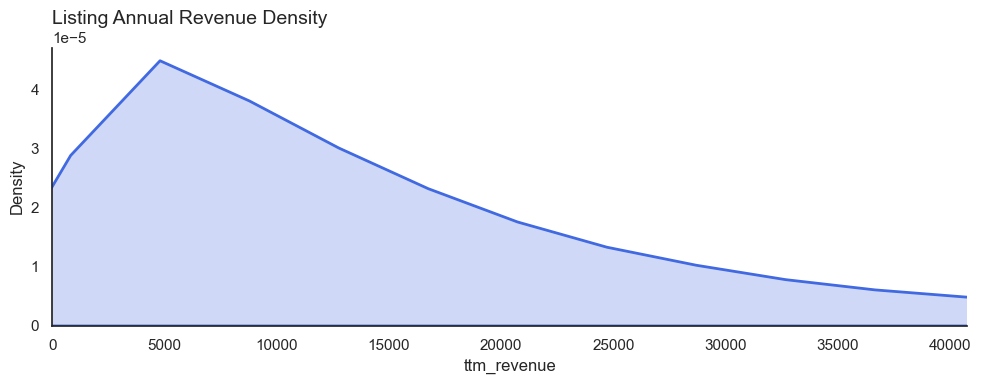

In [9]:
plt.figure(figsize=(10, 4))
sns.kdeplot(data=listings, x='ttm_revenue', fill=True, color='royalblue', lw=2)
plt.title('Listing Annual Revenue Density', fontsize=14, loc='left')
plt.xlim(0, listings['ttm_revenue'].quantile(0.9))
sns.despine()
plt.show()

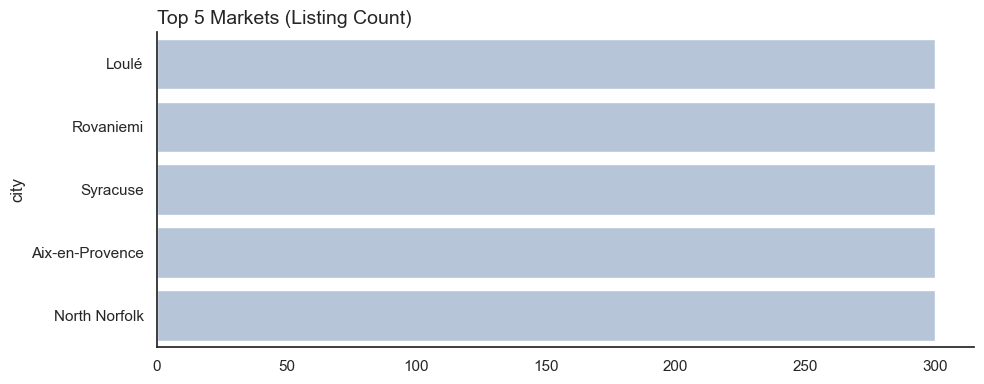

In [10]:
plt.figure(figsize=(10, 4))
top_cities = listings['city'].value_counts().head(5)
sns.barplot(x=top_cities.values, y=top_cities.index, color='lightsteelblue')
plt.title('Top 5 Markets (Listing Count)', fontsize=14, loc='left')
sns.despine()
plt.show()

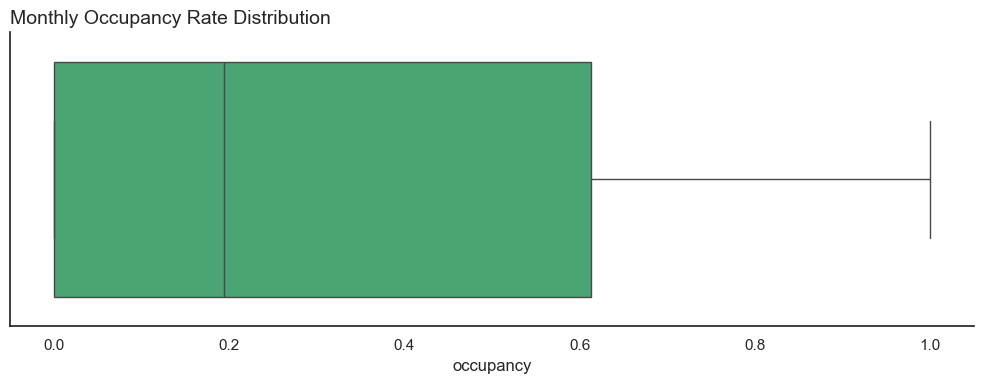

In [11]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=past_rates, x='occupancy', color='mediumseagreen', fliersize=1)
plt.title('Monthly Occupancy Rate Distribution', fontsize=14, loc='left')
sns.despine()
plt.show()

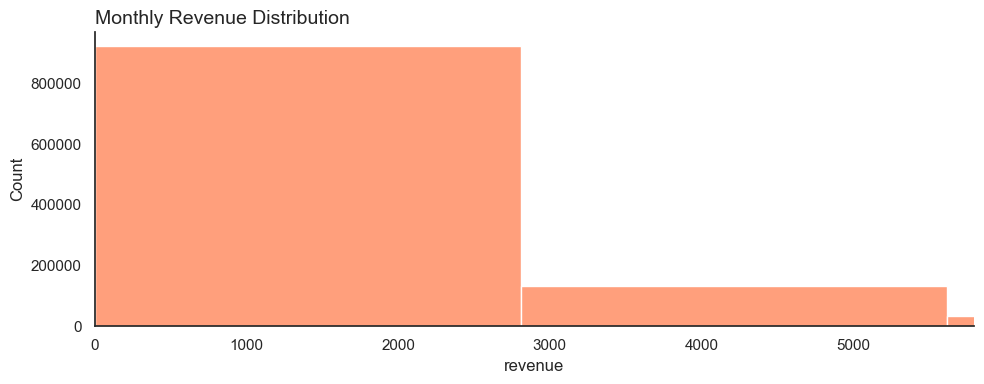

In [12]:
plt.figure(figsize=(10, 4))
sns.histplot(past_rates['revenue'], bins=40, color='coral', edgecolor='white')
plt.title('Monthly Revenue Distribution', fontsize=14, loc='left')
plt.xlim(0, past_rates['revenue'].quantile(0.95))
sns.despine()
plt.show()

## 2. Bivariate Analysis

/var/folders/jq/th0vcfvs2js6n7b3t8b1cn_40000gn/T/ipykernel_58571/1377836963.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=type_rev.values, y=type_rev.index, palette='Blues_r')


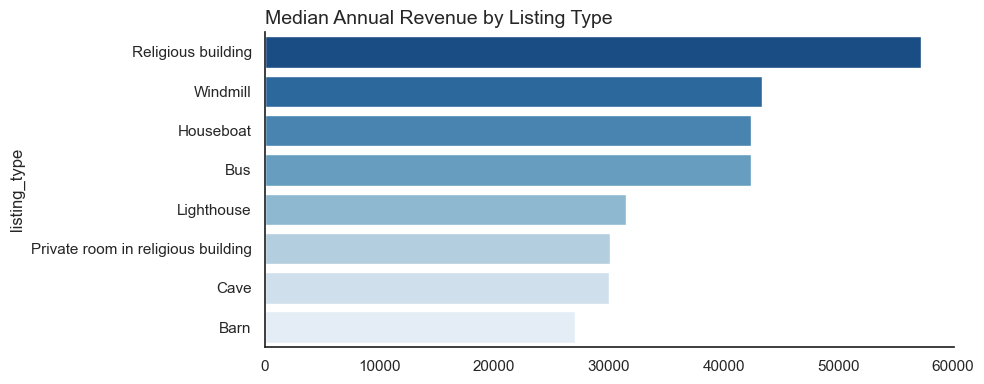

In [13]:
plt.figure(figsize=(10, 4))
type_rev = listings.groupby('listing_type')['ttm_revenue'].median().sort_values(ascending=False).head(8)
sns.barplot(x=type_rev.values, y=type_rev.index, palette='Blues_r')
plt.title('Median Annual Revenue by Listing Type', fontsize=14, loc='left')
sns.despine()
plt.show()

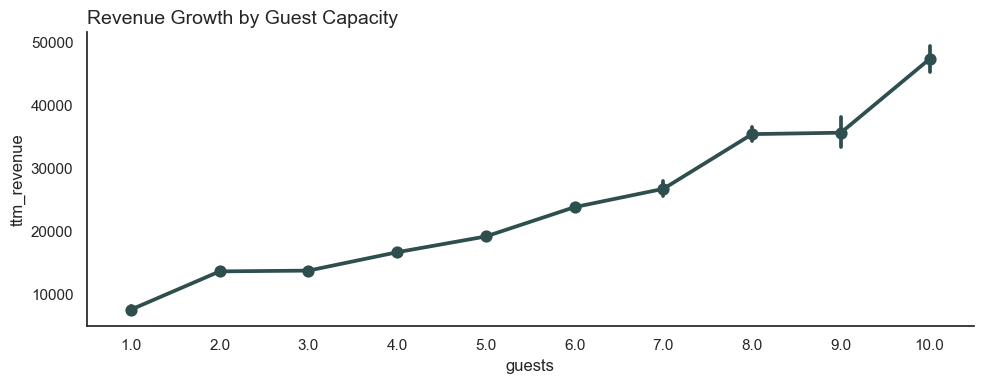

In [14]:
plt.figure(figsize=(10, 4))
sns.pointplot(data=listings[listings['guests'] <= 10], x='guests', y='ttm_revenue', linestyles='-', markers='o', color='darkslategray')
plt.title('Revenue Growth by Guest Capacity', fontsize=14, loc='left')
sns.despine()
plt.show()

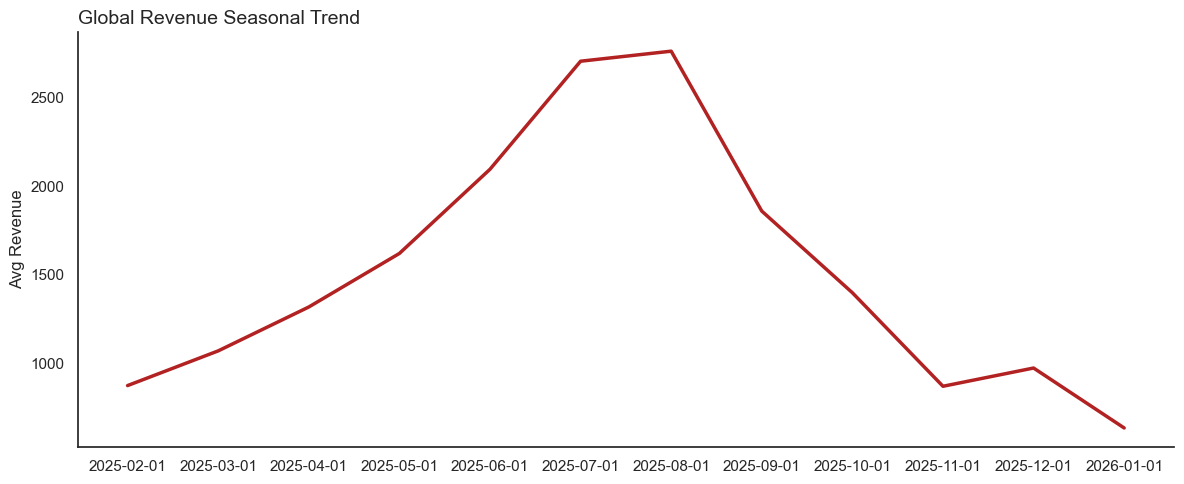

In [15]:
plt.figure(figsize=(12, 5))
monthly_agg = past_rates.groupby('date')['revenue'].mean()
plt.plot(monthly_agg.index, monthly_agg.values, color='firebrick', lw=2.5)
plt.title('Global Revenue Seasonal Trend', fontsize=14, loc='left')
plt.ylabel('Avg Revenue')
sns.despine()
plt.show()

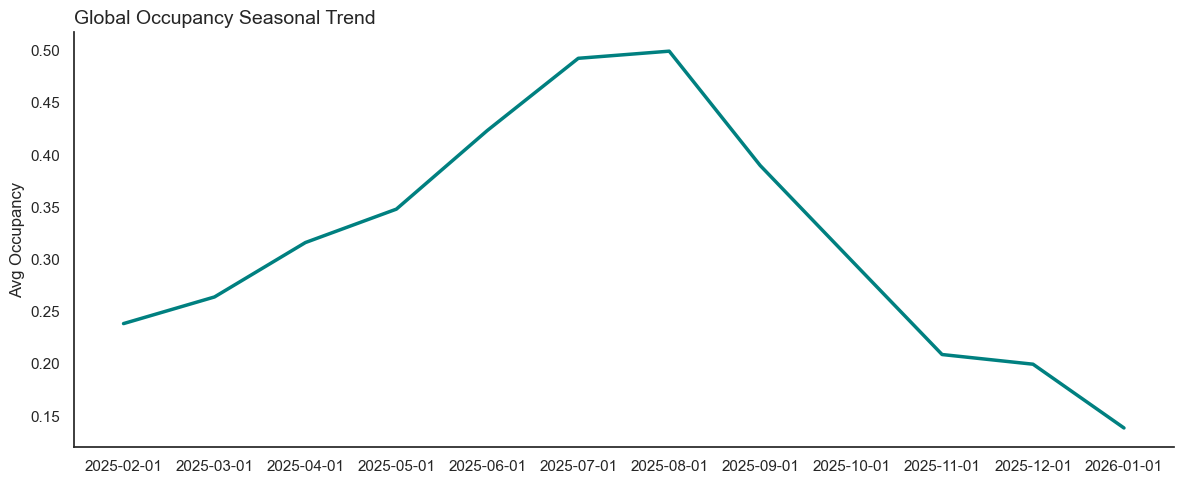

In [16]:
plt.figure(figsize=(12, 5))
monthly_occ = past_rates.groupby('date')['occupancy'].mean()
plt.plot(monthly_occ.index, monthly_occ.values, color='teal', lw=2.5)
plt.title('Global Occupancy Seasonal Trend', fontsize=14, loc='left')
plt.ylabel('Avg Occupancy')
sns.despine()
plt.show()

## 3. Multivariate Analysis

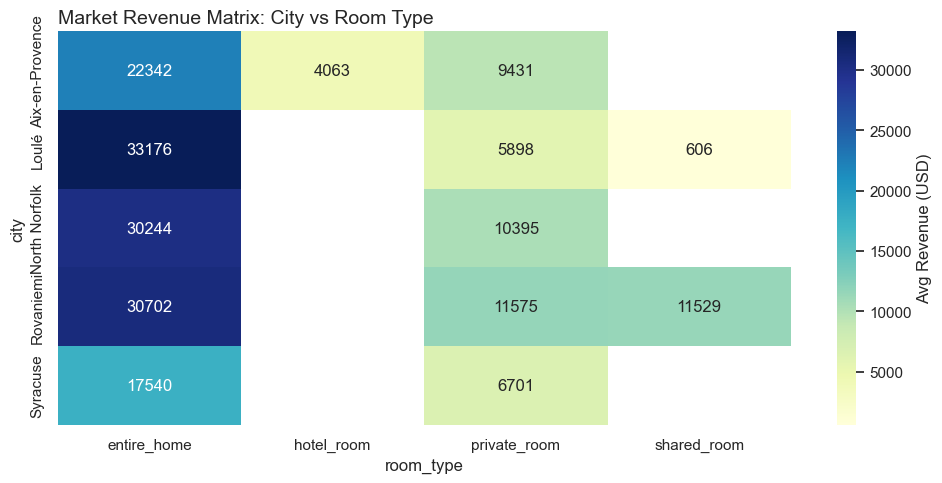

In [17]:
top_cities_full = listings['city'].value_counts().head(5).index
pivot_df = listings[listings['city'].isin(top_cities_full)].pivot_table(values='ttm_revenue', index='city', columns='room_type', aggfunc='mean')
plt.figure(figsize=(10, 5))
sns.heatmap(pivot_df, annot=True, fmt='.0f', cmap='YlGnBu', cbar_kws={'label': 'Avg Revenue (USD)'})
plt.title('Market Revenue Matrix: City vs Room Type', fontsize=14, loc='left')
plt.show()

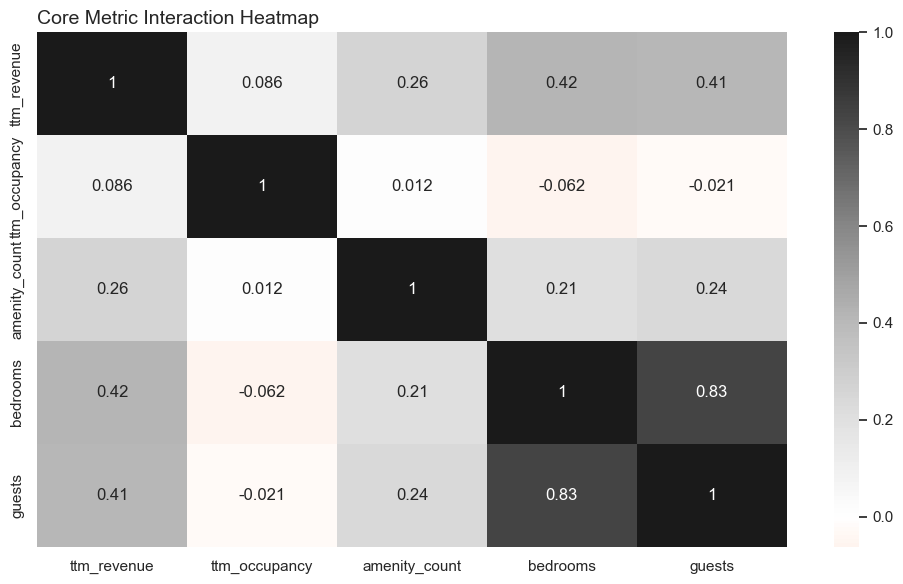

In [18]:
plt.figure(figsize=(10, 6))
corr = listings[['ttm_revenue', 'ttm_occupancy', 'amenity_count', 'bedrooms', 'guests']].corr()
sns.heatmap(corr, annot=True, cmap='RdGy', center=0)
plt.title('Core Metric Interaction Heatmap', fontsize=14, loc='left')
plt.show()

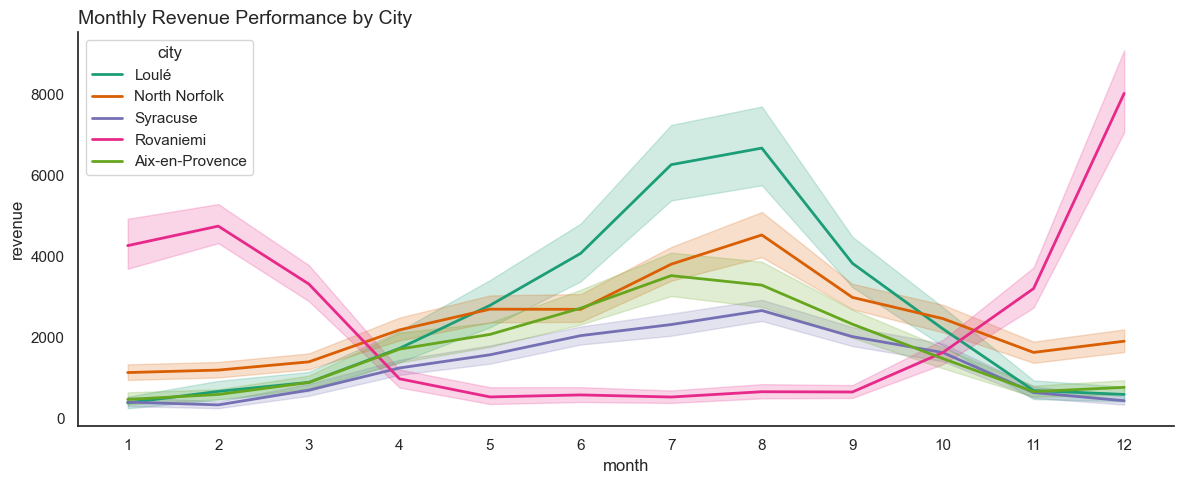

In [19]:
plt.figure(figsize=(12, 5))
city_seasonal = past_rates[past_rates['city'].isin(top_cities_full)].copy()
city_seasonal['date'] = pd.to_datetime(city_seasonal['date'])
city_seasonal['month'] = city_seasonal['date'].dt.month
sns.lineplot(data=city_seasonal, x='month', y='revenue', hue='city', palette='Dark2', lw=2)
plt.title('Monthly Revenue Performance by City', fontsize=14, loc='left')
plt.xticks(range(1,13))
sns.despine()
plt.show()

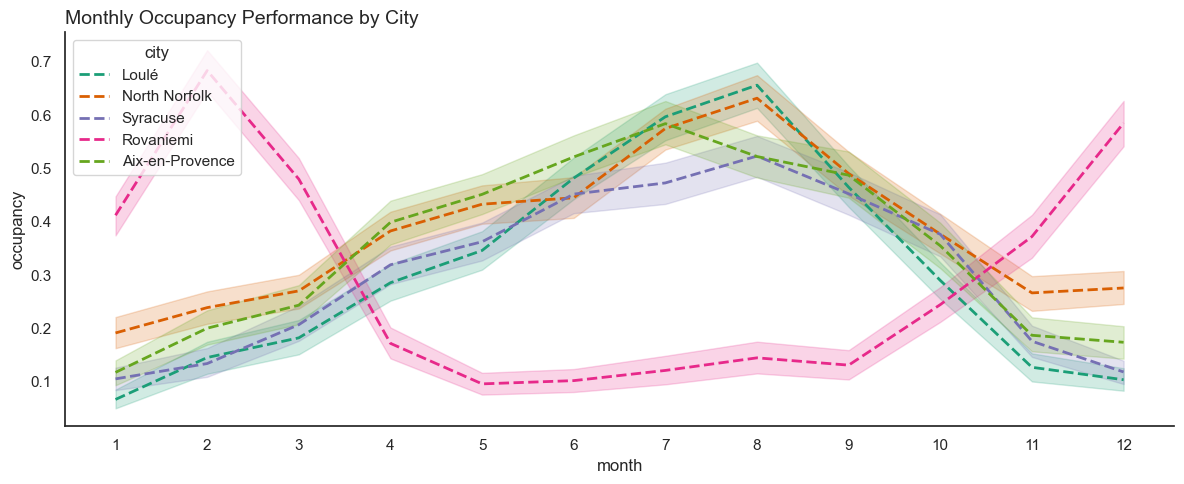

In [20]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=city_seasonal, x='month', y='occupancy', hue='city', palette='Dark2', lw=2, linestyle='--')
plt.title('Monthly Occupancy Performance by City', fontsize=14, loc='left')
plt.xticks(range(1,13))
sns.despine()
plt.show()